In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import re

In [10]:
!pip install emoji

In [11]:
pip install --upgrade nltk

In [12]:
import emoji
import nltk
from nltk.corpus import stopwords
from nltk.stem import SnowballStemmer
nltk.download('stopwords', quiet=True)

True

In [13]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [14]:
path = "/content/drive/MyDrive/TER/exports/brute_merged_emotion_oneshot.csv"
path2 = "/content/drive/MyDrive/TER/exports/brute_merged_emotyc_oneshot.csv"

In [15]:

CSV_PATH  = path
CSV_PATH2 = path2
TEXT_COL  = 'full_text'            # nom de la colonne texte
LABEL_COL = 'Perspective_label'           # nom de la colonne label (0/1 ou haineux/non-haineux)
SEP       = ','               # séparateur CSV
ENCODING  = 'utf-8'           # encodage (essaie 'latin-1' si erreur)
# ─────────────────────────────────────────────

df = pd.read_csv(CSV_PATH, sep=SEP, encoding=ENCODING)
df2 = pd.read_csv(CSV_PATH2, sep=SEP, encoding=ENCODING)


In [16]:
merged_df = pd.merge(df, df2, on=[TEXT_COL, LABEL_COL], how='outer', suffixes=('_df1', '_df2'))
print(f"Shape of original df: {df.shape}")
print(f"Shape of df2: {df2.shape}")
print(f"Shape of merged_df after merge: {merged_df.shape}")
print("\nFirst 5 rows of merged_df:")
print(merged_df.head())

Shape of original df: (1264, 31)
Shape of df2: (1264, 24)
Shape of merged_df after merge: (1264, 53)

First 5 rows of merged_df:
           user_df1                                           text_df1  \
0            Oz_aka  "Bonjour,\n\nC'est votre compte formation du f...   
1  GeorgesAbitbol42  "But the French supporters of national soverei...   
2           zazaeir  "C'est la merde, vos enfants vont douiller. Je...   
3      Mak_frenchie  "Dernière précision, de quel employeur s'agit-...   
4           oakpope  "Les Républicains et Ensemble (LREM+Horizons+M...   

  title_df1  Perspective_label  \
0       NaN                  0   
1       NaN                  0   
2       NaN                  1   
3       NaN                  1   
4       NaN                  0   

                                           full_text  found_df1  \
0  "Bonjour, C'est votre compte formation du futu...      False   
1  "But the French supporters of national soverei...       True   
2  "C'est la merde, 

In [17]:
df = merged_df

In [18]:
df.columns

Index(['user_df1', 'text_df1', 'title_df1', 'Perspective_label', 'full_text',
       'found_df1', 'text_clean_stemmed_df1', 'text_clean_df1', 'admiration',
       'amour', 'apaisement', 'audace', 'colere', 'comportement',
       'culpabilite', 'degout', 'deplaisir', 'desir', 'embarras', 'empathie',
       'fierte', 'impassibilite', 'inhumanite', 'joie', 'mepris',
       'non_specifiee', 'orgueil', 'peur', 'ressentiment', 'surprise',
       'tristesse', 'user_df2', 'text_df2', 'title_df2',
       'avec_emo_comportementale', 'avec_cat_fierte', 'avec_emo_complexe',
       'avec_cat_colere', 'avec_cat_joie', 'avec_cat_autre',
       'avec_cat_tristesse', 'avec_emo', 'avec_cat_surprise',
       'avec_emo_designee', 'avec_emo_base', 'avec_cat_peur',
       'avec_cat_admiration', 'avec_emo_montree', 'avec_emo_suggeree',
       'avec_cat_embarras', 'found_df2', 'text_clean_stemmed_df2',
       'text_clean_df2'],
      dtype='object')

In [19]:
df = df.drop(columns=['text_clean_stemmed_df2','text_clean_df2'])

In [24]:
df.columns

Index(['user_df1', 'text_df1', 'title_df1', 'Perspective_label', 'full_text',
       'found_df1', 'text_clean_stemmed_df1', 'text_clean_df1', 'admiration',
       'amour', 'apaisement', 'audace', 'colere', 'comportement',
       'culpabilite', 'degout', 'deplaisir', 'desir', 'embarras', 'empathie',
       'fierte', 'impassibilite', 'inhumanite', 'joie', 'mepris',
       'non_specifiee', 'orgueil', 'peur', 'ressentiment', 'surprise',
       'tristesse', 'user_df2', 'text_df2', 'title_df2',
       'avec_emo_comportementale', 'avec_cat_fierte', 'avec_emo_complexe',
       'avec_cat_colere', 'avec_cat_joie', 'avec_cat_autre',
       'avec_cat_tristesse', 'avec_emo', 'avec_cat_surprise',
       'avec_emo_designee', 'avec_emo_base', 'avec_cat_peur',
       'avec_cat_admiration', 'avec_emo_montree', 'avec_emo_suggeree',
       'avec_cat_embarras', 'found_df2'],
      dtype='object')

In [25]:
CATEGORIELLES_OH = ['found_df1','found_df2', 'avec_cat_joie',
       'avec_cat_admiration', 'avec_cat_tristesse', 'avec_cat_surprise',
       'avec_emo_comportementale', 'avec_cat_autre', 'avec_emo_designee',
       'avec_emo', 'avec_emo_base', 'avec_emo_suggeree', 'avec_cat_embarras',
       'avec_cat_colere', 'avec_cat_fierte', 'avec_emo_complexe',
       'avec_emo_montree', 'avec_cat_peur',
       'admiration', 'amour', 'apaisement', 'audace', 'colere', 'comportement',
       'culpabilite', 'desir', 'degout', 'embarras', 'fierte', 'inhumanite',
       'joie', 'mepris', 'non_specifiee', 'peur', 'ressentiment', 'surprise',
       'tristesse']

══════════════════════════════════════════════════════════════════════
  CROSS-VALIDATION 5 FOLDS
══════════════════════════════════════════════════════════════════════

──────────────────────────────────────────────────────────────────────
  VERSION : SANS STEMMING
──────────────────────────────────────────────────────────────────────
  Modèle                      Accuracy   F1-macro  Précision     Recall
  ───────────────────────── ────────── ────────── ────────── ──────────
  Random Forest                  0.809     0.588      0.583      0.847  (±0.035)
  Naive Bayes                    0.774     0.700      0.718      0.690  (±0.029)
  SVM Linéaire                   0.830     0.715      0.689      0.777  (±0.024)
  Régression Logistique          0.809     0.585      0.581      0.861  (±0.031)

──────────────────────────────────────────────────────────────────────
  VERSION : AVEC STEMMING
──────────────────────────────────────────────────────────────────────
  Modèle                 

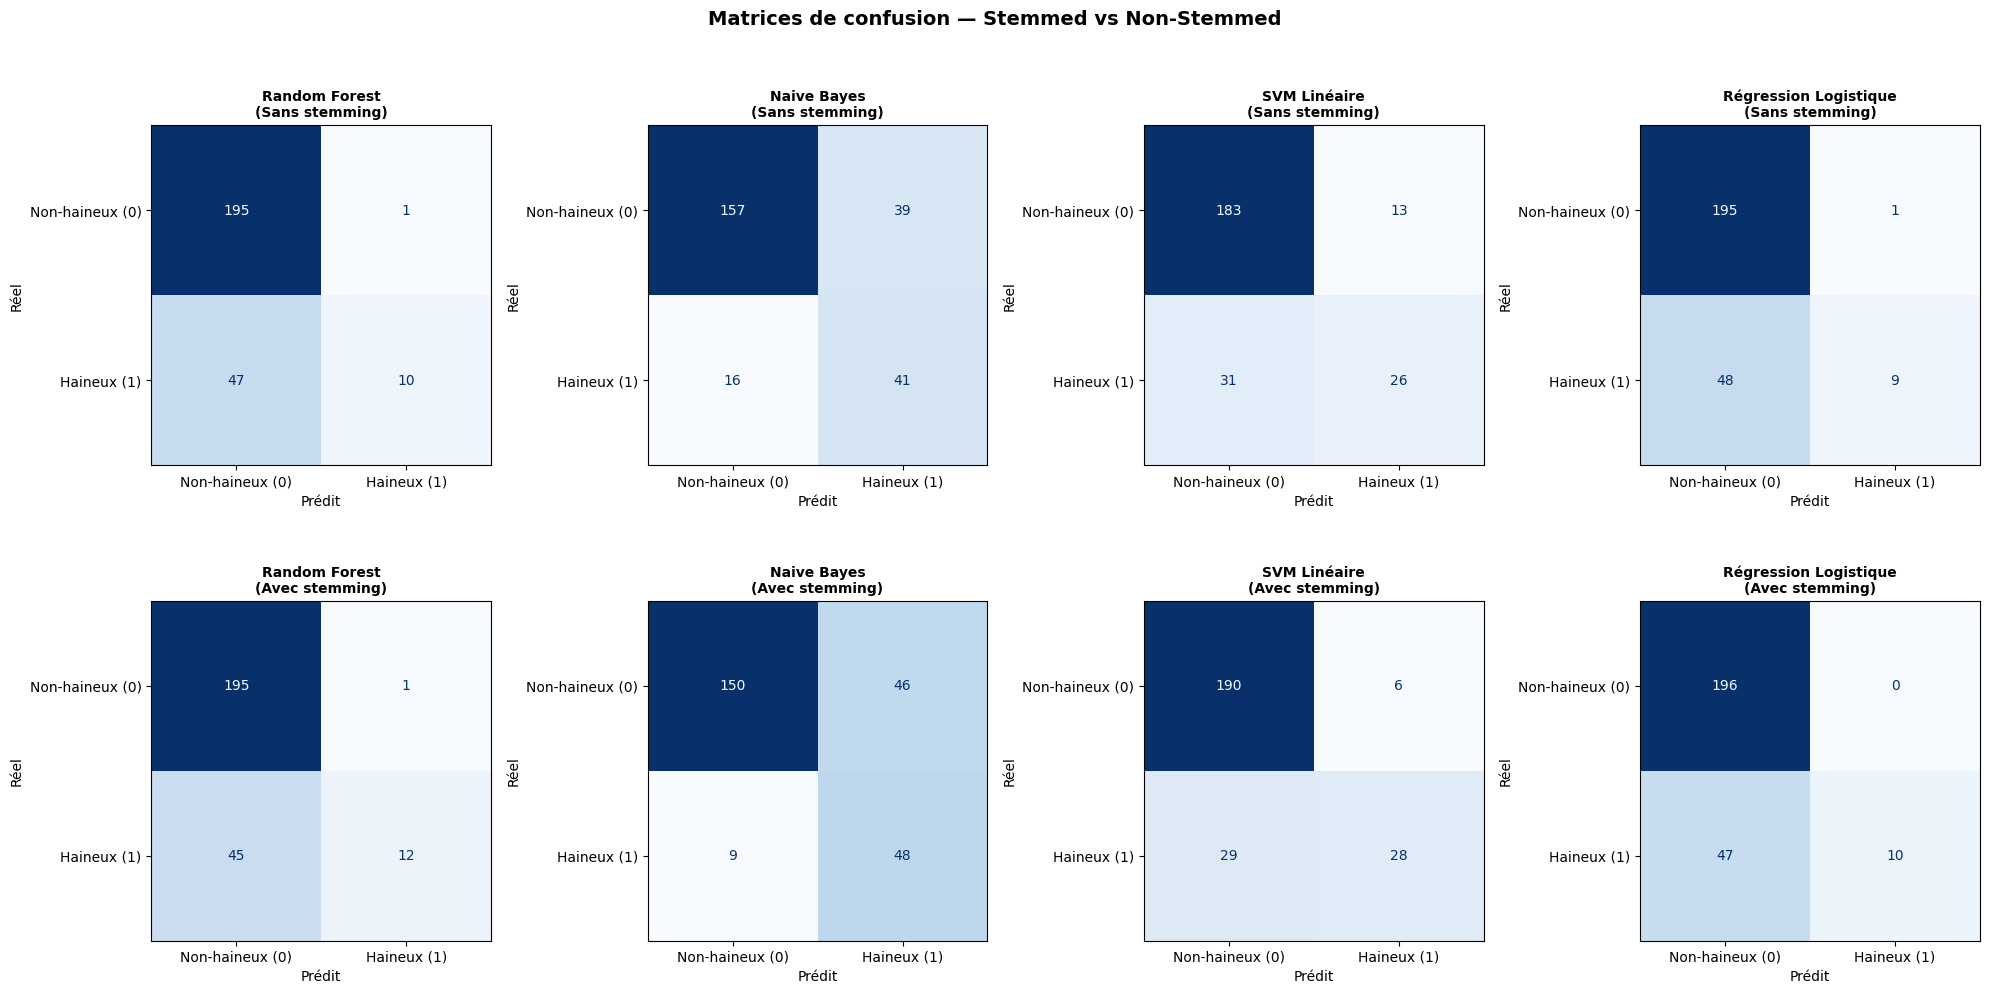

In [27]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import StratifiedKFold, cross_validate, train_test_split
from sklearn.naive_bayes import ComplementNB
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import matplotlib.pyplot as plt
import numpy as np
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier


VERSIONS = {
    'Sans stemming' : df[['text_clean_df1'] + CATEGORIELLES_OH].rename(columns={'text_clean_df1': 'text'}).fillna(''),
    'Avec stemming' : df[['text_clean_stemmed_df1'] + CATEGORIELLES_OH].rename(columns={'text_clean_stemmed_df1': 'text'}).fillna(''),
}

MODELES = {
    'Random Forest'        : RandomForestClassifier(n_estimators=100, random_state=42),
    'Naive Bayes'          : ComplementNB(),
    'SVM Linéaire'         : LinearSVC(max_iter=1500, random_state=42),
    'Régression Logistique': LogisticRegression(max_iter=1500, random_state=42),
}

METRIQUES = ['accuracy', 'f1_macro', 'precision_macro', 'recall_macro']

y = df[LABEL_COL]
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

def make_pipeline(clf):
    preprocessor = ColumnTransformer([
        ('text', TfidfVectorizer(
            ngram_range=(1,1),
            sublinear_tf=True,
            max_features=20000,
            min_df=2
        ), 'text'),

        ('cat', 'passthrough', CATEGORIELLES_OH)
    ])

    return Pipeline([
        ('preprocess', preprocessor),
        ('clf', clf)
    ])

print('═'*70)
print('  CROSS-VALIDATION 5 FOLDS')
print('═'*70)

tous_resultats = {}

for version_nom, X in VERSIONS.items():
    print(f'\n{"─"*70}')
    print(f'  VERSION : {version_nom.upper()}')
    print(f'{"─"*70}')
    print(f'  {"Modèle":<25} {"Accuracy":>10} {"F1-macro":>10} {"Précision":>10} {"Recall":>10}')
    print(f'  {"─"*25} {"─"*10} {"─"*10} {"─"*10} {"─"*10}')

    for nom_clf, clf in MODELES.items():
        pipeline = make_pipeline(clf)
        scores = cross_validate(pipeline, X, y, cv=cv, scoring=METRIQUES)
        tous_resultats[(version_nom, nom_clf)] = scores

        acc = scores['test_accuracy'].mean()
        f1  = scores['test_f1_macro'].mean()
        pre = scores['test_precision_macro'].mean()
        rec = scores['test_recall_macro'].mean()
        std = scores['test_f1_macro'].std()

        print(f'  {nom_clf:<25} {acc:>10.3f} {f1:>9.3f} {rec:>10.3f} {pre:>10.3f}  (±{std:.3f})')


print(f'\n\n{"═"*70}')
print('  MATRICES DE CONFUSION — Ensemble test final (80/20)')
print('═'*70)

noms_classes = ['Non-haineux (0)', 'Haineux (1)']
n_versions   = len(VERSIONS)
n_modeles    = len(MODELES)

fig, axes = plt.subplots(
    n_versions, n_modeles,
    figsize=(5 * n_modeles, 5 * n_versions)
)
fig.suptitle('Matrices de confusion — Stemmed vs Non-Stemmed', fontsize=14, fontweight='bold', y=1.01)

for i, (version_nom, X) in enumerate(VERSIONS.items()):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    for j, (nom_clf, clf) in enumerate(MODELES.items()):
        pipeline = make_pipeline(clf)
        pipeline.fit(X_train, y_train)
        y_pred = pipeline.predict(X_test)

        cm = confusion_matrix(y_test, y_pred)
        ax = axes[i][j]

        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=noms_classes)
        disp.plot(ax=ax, colorbar=False, cmap='Blues')

        ax.set_title(f'{nom_clf}\n({version_nom})', fontsize=10, fontweight='bold')
        ax.set_xlabel('Prédit')
        ax.set_ylabel('Réel')

        # Rapport textuel
        print(f'\n── {nom_clf} | {version_nom} ──')
        print(classification_report(y_test, y_pred, target_names=noms_classes))

plt.tight_layout()
plt.show()

══════════════════════════════════════════════════════════════════════
  DIAGNOSTIC OVERFITTING / UNDERFITTING
══════════════════════════════════════════════════════════════════════

── Random Forest | Sans stemming ──
  F1 Train : 0.996
  F1 Test  : 0.592
  Gap      : 0.403

── Naive Bayes | Sans stemming ──
  F1 Train : 0.842
  F1 Test  : 0.725
  Gap      : 0.118

── SVM Linéaire | Sans stemming ──
  F1 Train : 0.996
  F1 Test  : 0.717
  Gap      : 0.279

── Régression Logistique | Sans stemming ──
  F1 Train : 0.741
  F1 Test  : 0.579
  Gap      : 0.163

── Random Forest | Avec stemming ──
  F1 Train : 0.996
  F1 Test  : 0.619
  Gap      : 0.377

── Naive Bayes | Avec stemming ──
  F1 Train : 0.815
  F1 Test  : 0.740
  Gap      : 0.074

── SVM Linéaire | Avec stemming ──
  F1 Train : 0.994
  F1 Test  : 0.766
  Gap      : 0.229

── Régression Logistique | Avec stemming ──
  F1 Train : 0.767
  F1 Test  : 0.596
  Gap      : 0.171


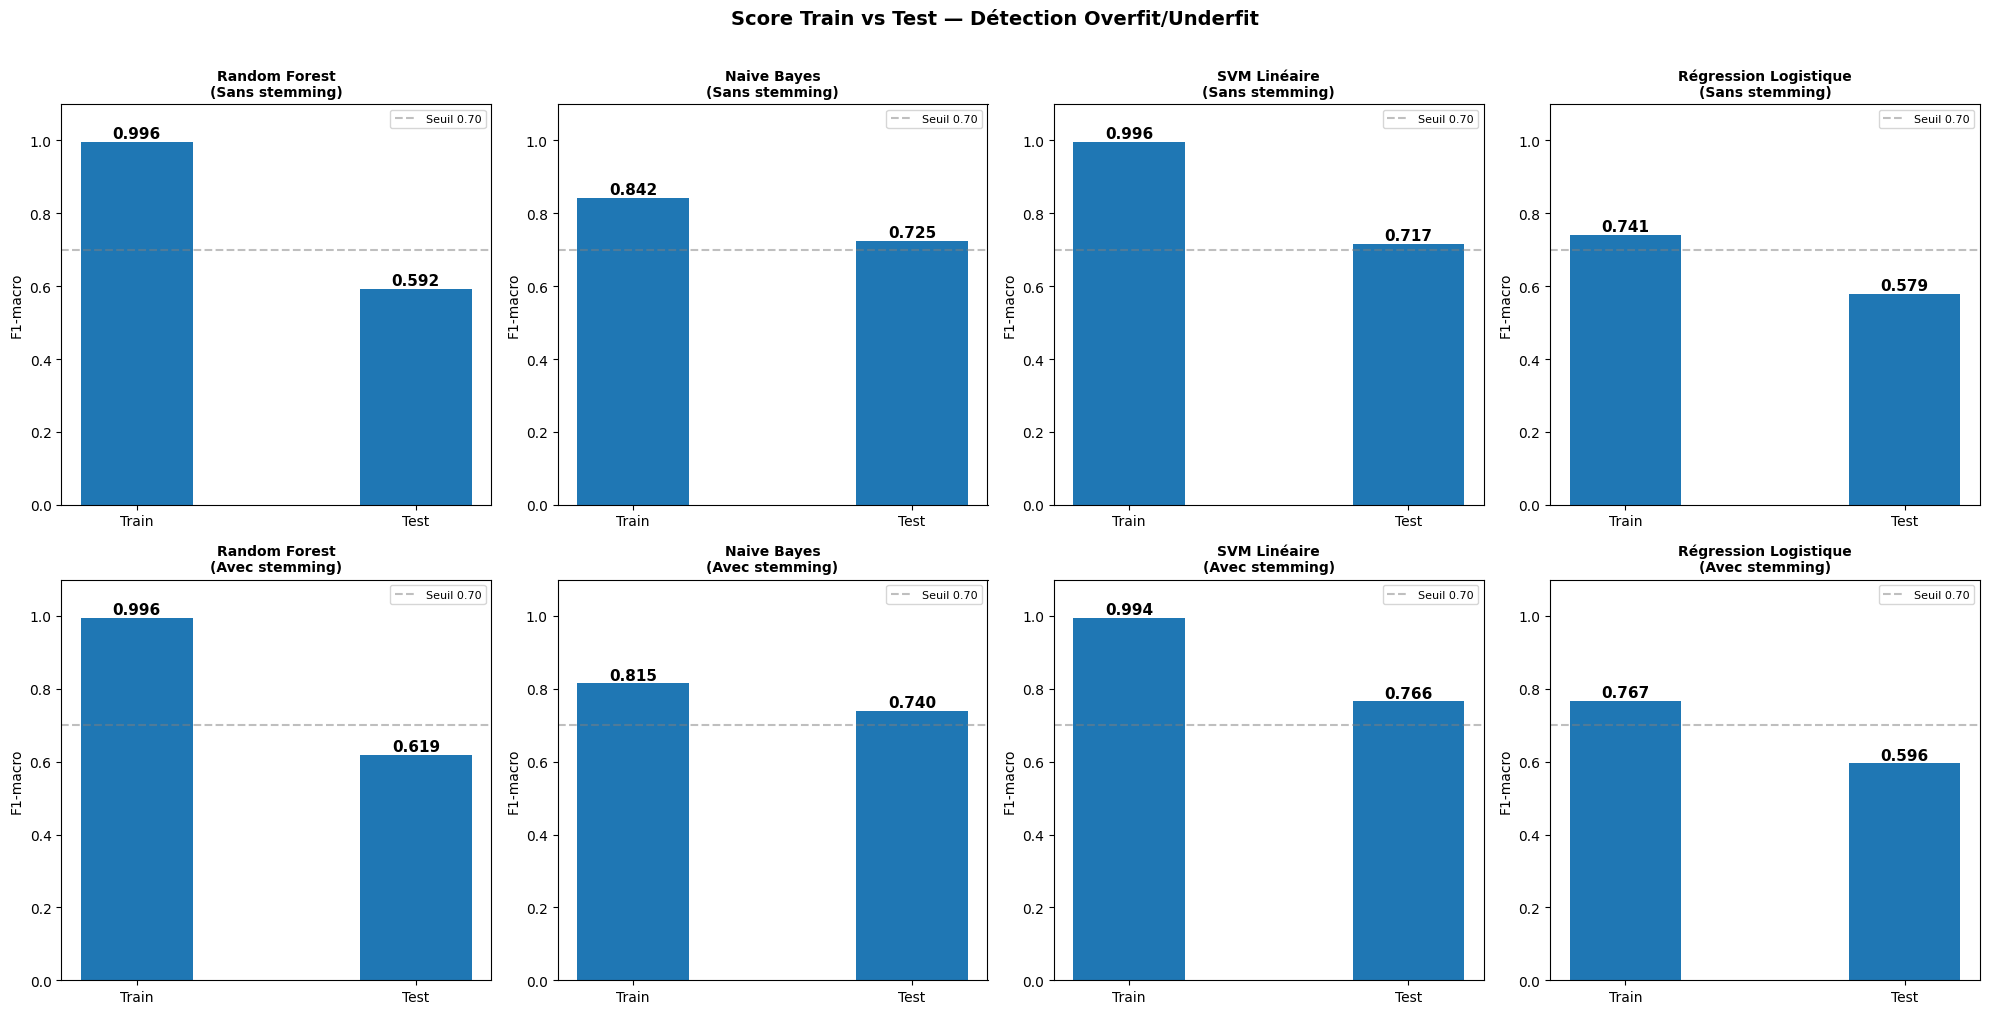

In [28]:


from sklearn.metrics import f1_score

print('═'*70)
print('  DIAGNOSTIC OVERFITTING / UNDERFITTING')
print('═'*70)

fig, axes = plt.subplots(n_versions, n_modeles, figsize=(5 * n_modeles, 5 * n_versions))
fig.suptitle('Score Train vs Test — Détection Overfit/Underfit', fontsize=14, fontweight='bold', y=1.01)

for i, (version_nom, X) in enumerate(VERSIONS.items()):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    for j, (nom_clf, clf) in enumerate(MODELES.items()):
        pipeline = make_pipeline(clf)
        pipeline.fit(X_train, y_train)

        # Score directement sur train et test
        score_train = f1_score(y_train, pipeline.predict(X_train), average='macro')
        score_test  = f1_score(y_test,  pipeline.predict(X_test),  average='macro')
        gap         = score_train - score_test



        # ── Affichage texte ───────────────────────────────────
        print(f'\n── {nom_clf} | {version_nom} ──')
        print(f'  F1 Train : {score_train:.3f}')
        print(f'  F1 Test  : {score_test:.3f}')
        print(f'  Gap      : {gap:.3f}')


        # ── Graphique barres ──────────────────────────────────
        ax = axes[i][j]
        bars = ax.bar(['Train', 'Test'], [score_train, score_test],
                      width=0.4)

        for bar, val in zip(bars, [score_train, score_test]):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                    f'{val:.3f}', ha='center', fontsize=11, fontweight='bold')

        ax.set_ylim(0, 1.1)
        ax.set_title(f'{nom_clf}\n({version_nom})', fontsize=10, fontweight='bold')
        ax.set_ylabel('F1-macro')
        ax.axhline(y=0.70, color='gray', linestyle='--', alpha=0.5, label='Seuil 0.70')
        ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

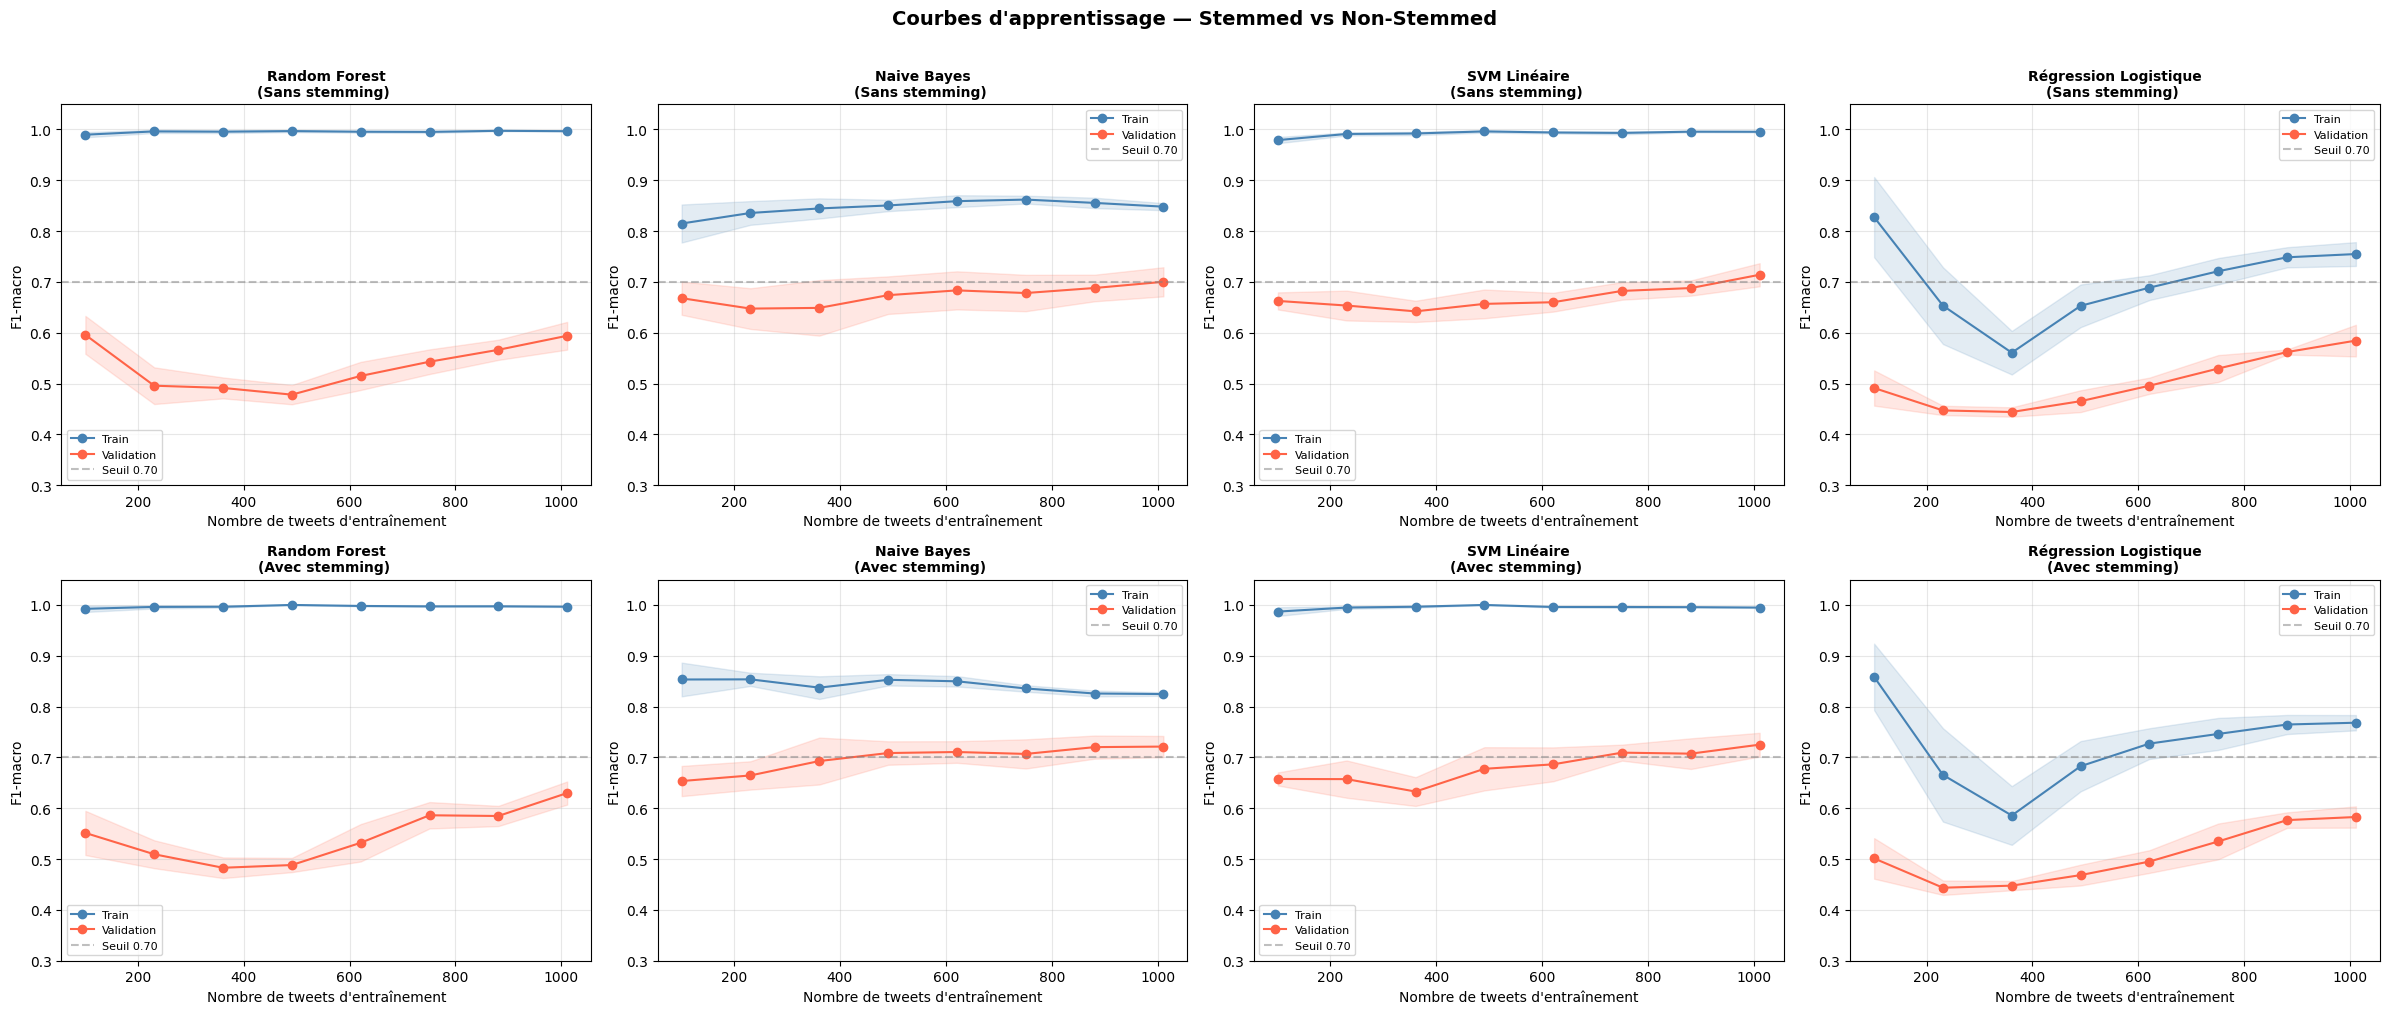

In [29]:


from sklearn.model_selection import learning_curve
n_versions = len(VERSIONS)
n_modeles  = len(MODELES)
fig, axes = plt.subplots(n_versions, n_modeles, figsize=(6 * n_modeles, 5 * n_versions))
fig.suptitle("Courbes d'apprentissage — Stemmed vs Non-Stemmed",
             fontsize=14, fontweight='bold', y=1.01)
train_sizes = np.linspace(0.1, 1.0, 8)

for i, (version_nom, X) in enumerate(VERSIONS.items()):
    for j, (nom_clf, clf) in enumerate(MODELES.items()):

        pipeline = make_pipeline(clf)

        train_sizes_abs, train_scores, val_scores = learning_curve(
            pipeline, X, y,
            train_sizes=train_sizes,
            cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
            scoring='f1_macro',
            n_jobs=-1
        )

        train_mean = train_scores.mean(axis=1)
        train_std  = train_scores.std(axis=1)
        val_mean   = val_scores.mean(axis=1)
        val_std    = val_scores.std(axis=1)



        # ── Tracé ─────────────────────────────────────────────
        ax = axes[i][j]

        ax.plot(train_sizes_abs, train_mean, 'o-', color='steelblue', label='Train')
        ax.fill_between(train_sizes_abs,
                        train_mean - train_std,
                        train_mean + train_std,
                        alpha=0.15, color='steelblue')

        ax.plot(train_sizes_abs, val_mean, 'o-', color='tomato', label='Validation')
        ax.fill_between(train_sizes_abs,
                        val_mean - val_std,
                        val_mean + val_std,
                        alpha=0.15, color='tomato')

        ax.axhline(y=0.70, color='gray', linestyle='--', alpha=0.5, label='Seuil 0.70')
        ax.set_title(f'{nom_clf}\n({version_nom}) ', fontsize=10, fontweight='bold')
        ax.set_xlabel("Nombre de tweets d'entraînement")
        ax.set_ylabel('F1-macro')
        ax.set_ylim(0.3, 1.05)
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
